# 03 — Deployment context and within-occupation variation

Two extensions of the main finding.

First: the same task looks very different depending on whether people access Claude via the **API** (programmatic, embedded in pipelines) or **Claude.ai** (interactive, conversational). This suggests automation is as much a deployment decision as a task characteristic.

Second: tasks within the same occupation vary widely in automation share. This means "will AI automate occupation X?" is under-specified — the answer depends on which tasks within that occupation you're asking about.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix
from src.features import compute_platform_gap, compute_within_occupation_heterogeneity

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

## API vs. Claude.ai

The March 2026 release includes separate data for Claude.ai (the web/app interface) and the 1P API (programmatic access). We match tasks across platforms and compare.

In [2]:
gap = compute_platform_gap()
print(f'{len(gap):,} tasks observed on both platforms')
print(f'Mean automation share — Claude.ai: {gap["automation_share"].mean():.0%},  API: {gap["automation_share_api"].mean():.0%}')
print(f'Mean gap (API - Claude.ai): {gap["automation_gap"].mean():+.0%}')

2,429 tasks observed on both platforms
Mean automation share — Claude.ai: 32%,  API: 57%
Mean gap (API - Claude.ai): +25%


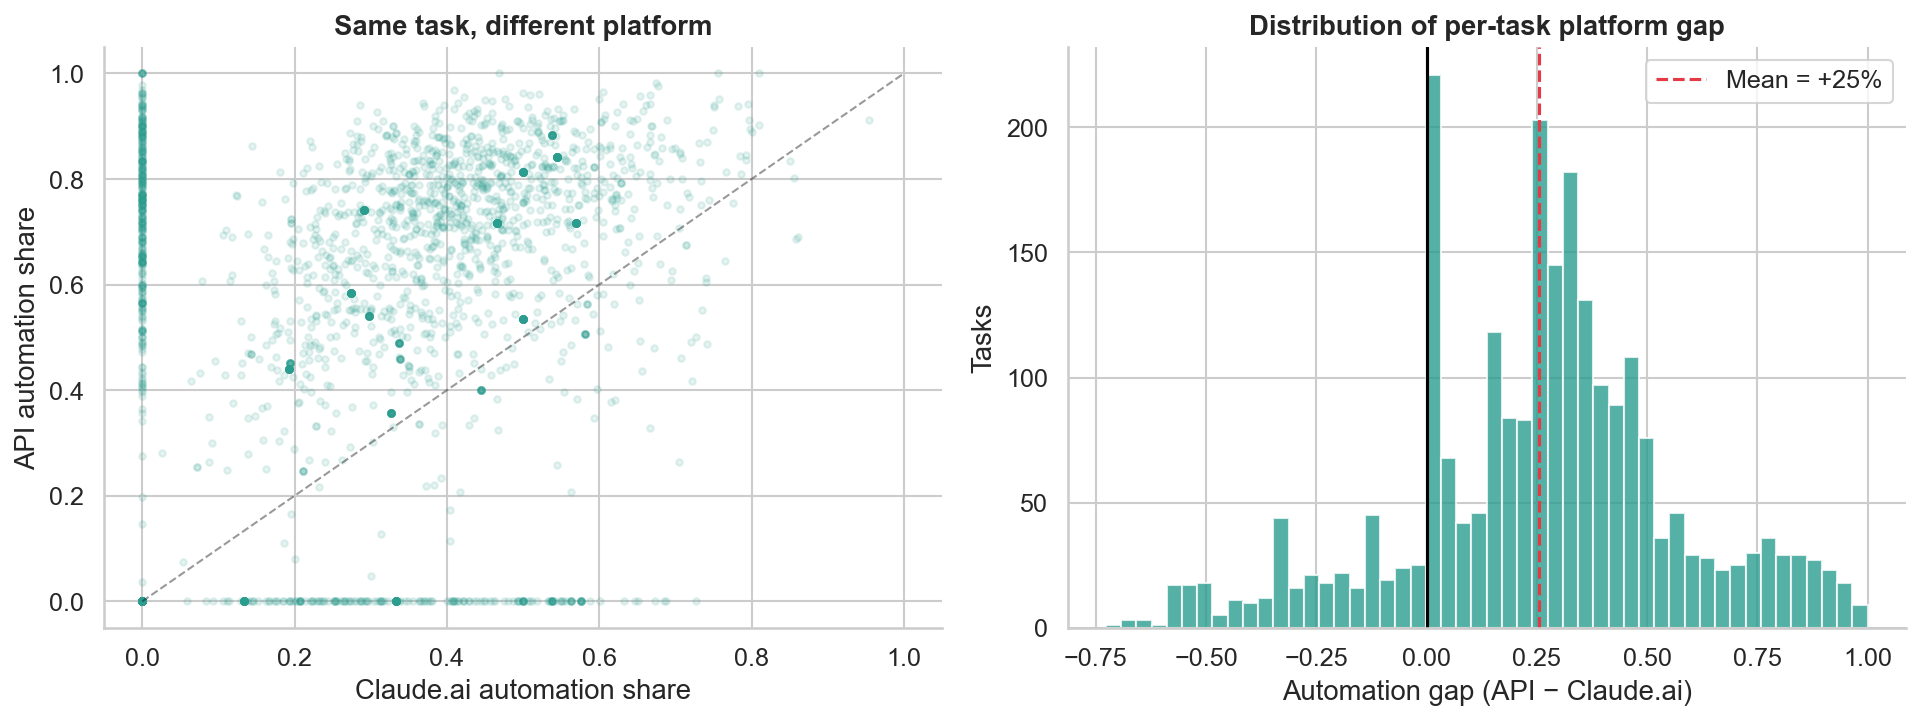

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(gap['automation_share'], gap['automation_share_api'],
           alpha=0.12, s=10, color='#2A9D8F')
ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1, alpha=0.4)
ax.set_xlabel('Claude.ai automation share')
ax.set_ylabel('API automation share')
ax.set_title('Same task, different platform', fontweight='bold')

ax = axes[1]
ax.hist(gap['automation_gap'], bins=50, color='#2A9D8F', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(gap['automation_gap'].mean(), color='#E63946', linestyle='--', linewidth=1.5,
           label=f'Mean = {gap["automation_gap"].mean():+.0%}')
ax.set_xlabel('Automation gap (API − Claude.ai)')
ax.set_ylabel('Tasks')
ax.set_title('Distribution of per-task platform gap', fontweight='bold')
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../figures/05_platform_gap.png', bbox_inches='tight')
plt.show()

In [4]:
# Tasks with the largest swing
extreme = gap[(gap['automation_share'] < 0.05) & (gap['automation_share_api'] > 0.9)]
print(f'{len(extreme)} tasks go from < 5% automation on Claude.ai to > 90% on API:\n')
for _, r in extreme.head(6).iterrows():
    print(f'  Claude.ai {r["automation_share"]:>3.0%} → API {r["automation_share_api"]:>3.0%}   {r["task_name"][:70]}')

44 tasks go from < 5% automation on Claude.ai to > 90% on API:

  Claude.ai  0% → API 92%   analyze statistical data and reports to identify and determine causes 
  Claude.ai  0% → API 92%   analyze statistical data and reports to identify and determine causes 
  Claude.ai  0% → API 100%   conduct needs assessments to identify document management requirements
  Claude.ai  0% → API 93%   consult sources such as rate books, manuals, or insurance company repr
  Claude.ai  0% → API 96%   coordinate sales or other promotional strategies with merchandising, o
  Claude.ai  0% → API 94%   develop prospects from current commercial customers, referral leads, o


This is not about AI capability — the model is the same. It is about how organizations choose to deploy it. When the same task is embedded in an automated pipeline (API), it becomes directive by construction.

## Within-occupation task variation

Occupation-level analyses assume the tasks within a job are reasonably homogeneous. They are not.

In [5]:
tasks = build_task_feature_matrix()
het = compute_within_occupation_heterogeneity(tasks)
het = het[het['n_tasks'] >= 5].sort_values('autonomy_range', ascending=False)

print(f'{len(het)} occupations with >= 5 tasks')
print(f'Median within-occupation autonomy range: {het["autonomy_range"].median():.2f} (on 1–5 scale)')
print(f'\nMost internally varied occupations:')
for _, r in het.head(8).iterrows():
    t = r['title'] if pd.notna(r['title']) else r['soc_code']
    print(f'  {t:45s}  range = {r["autonomy_range"]:.1f}  ({r["n_tasks"]:.0f} tasks)')

319 occupations with >= 5 tasks
Median within-occupation autonomy range: 0.64 (on 1–5 scale)

Most internally varied occupations:
  Word Processors and Typists                    range = 1.8  (10 tasks)
  First-Line Supervisors of Office and Administrative Support Workers  range = 1.7  (16 tasks)
  Cashiers                                       range = 1.4  (5 tasks)
  Teacher Assistants                             range = 1.3  (11 tasks)
  Technical Writers                              range = 1.3  (8 tasks)
  Fraud Examiners, Investigators and Analysts    range = 1.2  (8 tasks)
  Door-To-Door Sales Workers, News and Street Vendors, and Related Workers  range = 1.2  (5 tasks)
  Bookkeeping, Accounting, and Auditing Clerks   range = 1.2  (12 tasks)


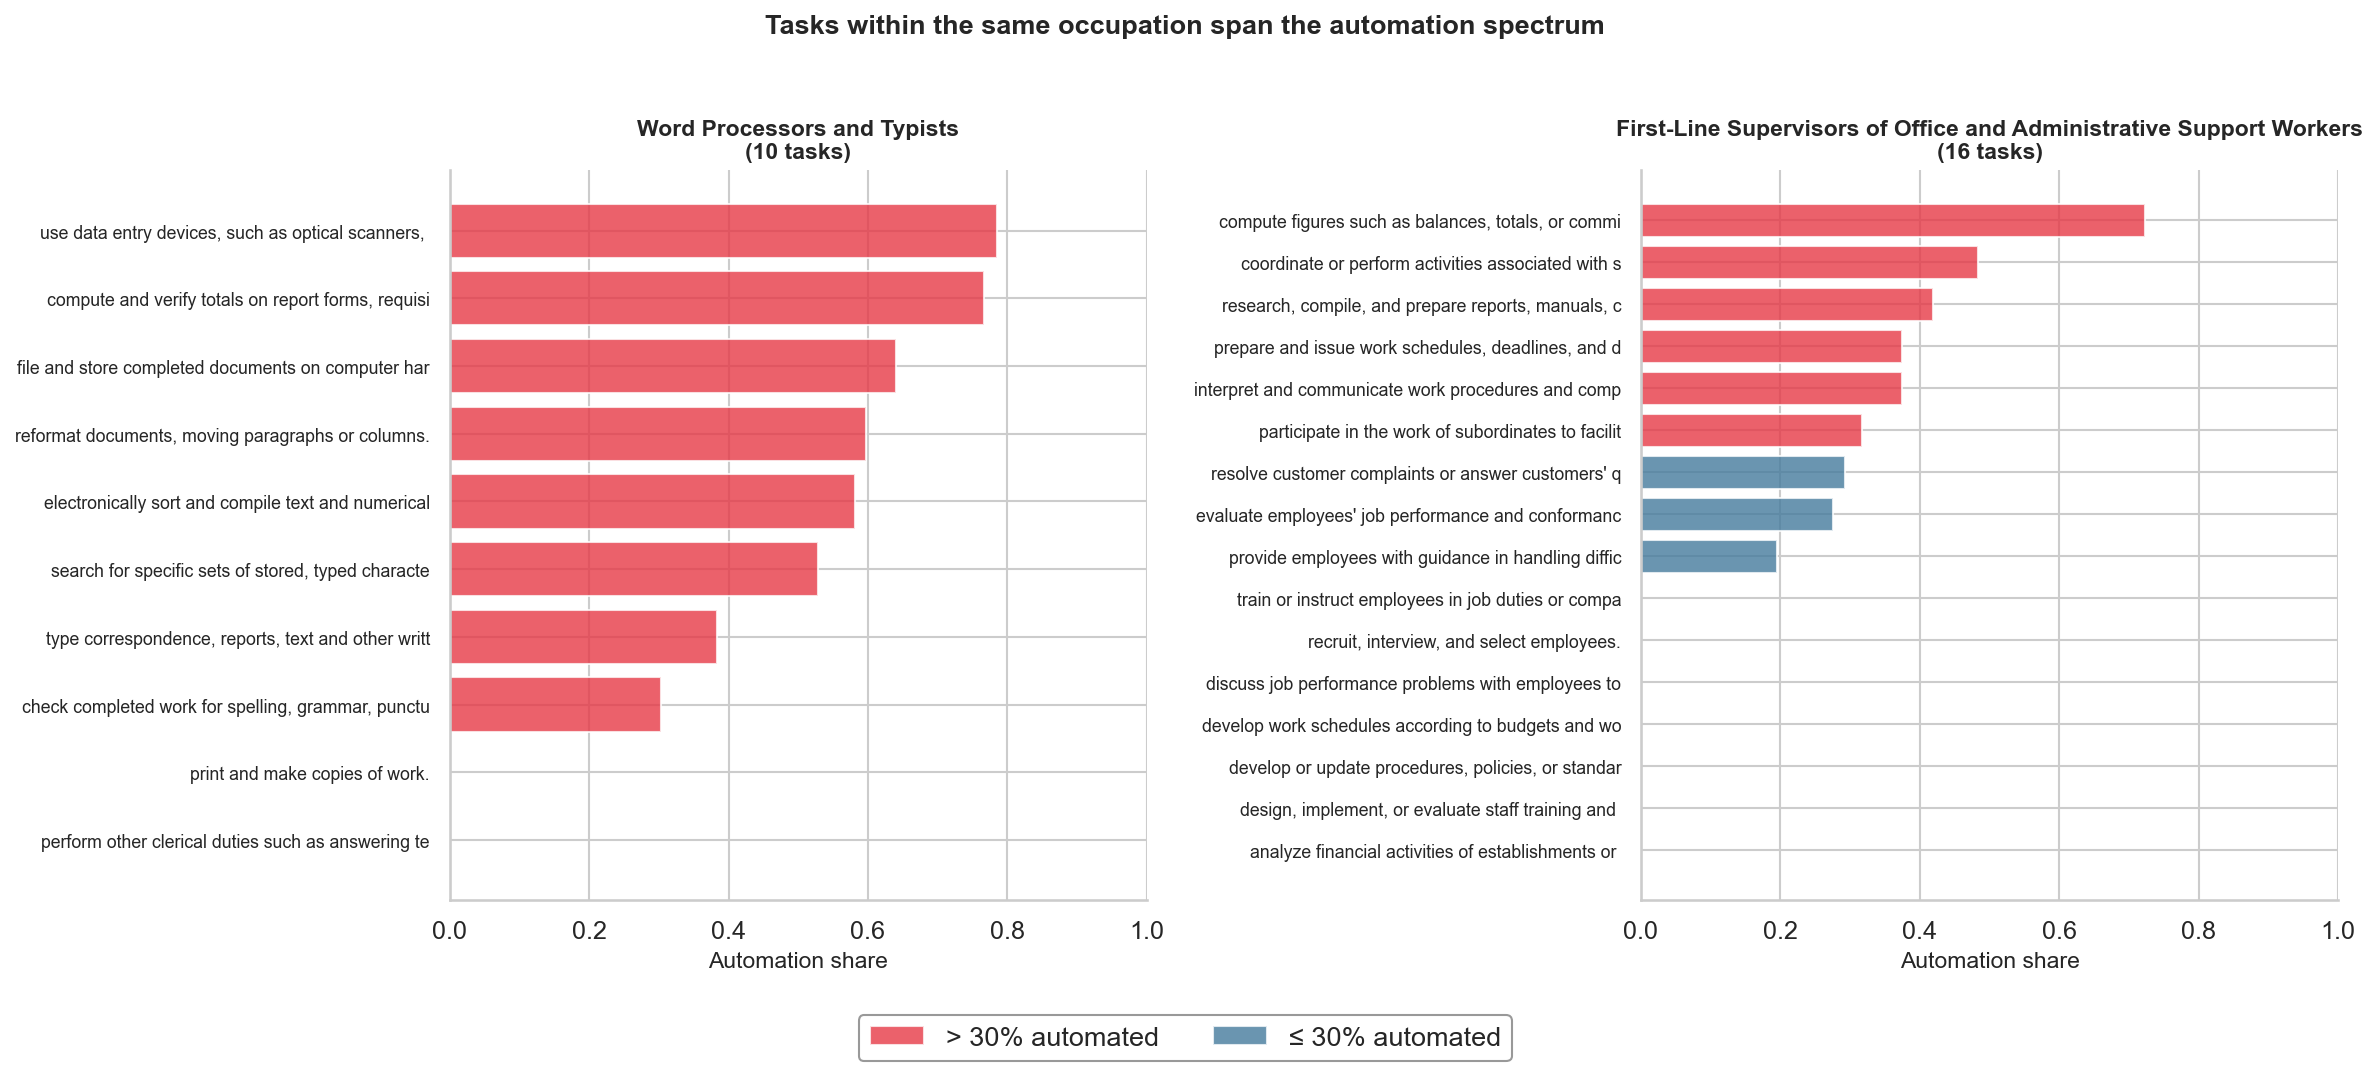

In [6]:
# Show 2 occupations side by side — large enough to read task labels
cases = het.head(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (_, occ) in zip(axes, cases.iterrows()):
    occ_tasks = tasks[tasks['soc_code'] == occ['soc_code']].drop_duplicates(subset='task_name')
    occ_tasks = occ_tasks.sort_values('automation_share')
    labels = [t[:50] for t in occ_tasks['task_name']]
    auto = occ_tasks['automation_share'].values
    colors = ['#E63946' if a > 0.3 else '#457B9D' for a in auto]
    ax.barh(range(len(auto)), auto, color=colors, alpha=0.8)
    ax.set_yticks(range(len(auto)))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Automation share', fontsize=11)
    title = occ['title'] if pd.notna(occ['title']) else occ['soc_code']
    ax.set_title(f'{title}\n({occ["n_tasks"]:.0f} tasks)', fontsize=11, fontweight='bold')

# Legend — centered below both panels, large text
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', alpha=0.8, label='> 30% automated'),
                   Patch(facecolor='#457B9D', alpha=0.8, label='≤ 30% automated')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=13, frameon=True, edgecolor='gray',
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Tasks within the same occupation span the automation spectrum',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('../figures/06_within_occupation.png', bbox_inches='tight')
plt.show()

Each panel is a single occupation. The tasks within it range from fully automated to fully augmented. Averaging across them — as occupation-level analyses do — obscures the structure that matters.

## Summary

Three patterns in how people use AI for occupational tasks:

1. **Output type over skill level.** Tasks that produce artifacts (reports, data, transcripts) are automated at roughly twice the rate of tasks that require human interaction (advising, teaching, negotiating). Education level has no measurable effect.

2. **Deployment over capability.** The same task can be 0% automated on Claude.ai and 100% automated on API. Automation is a deployment decision.

3. **Tasks over jobs.** Tasks within the same occupation span the full automation spectrum. Occupation-level analysis is the wrong unit.